# 1. Load and Preprocess Data


Here is where we are going to prepare the dataset for training our machine learning models.

Let's load the data into a Pandas DataFrame. Each row represents a sample (client), and each column represents a feature (such as ethnicity, annual income, industry category) or the Outcome.




In [ ]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("samuelcortinhas/credit-card-approval-clean-data")

df_application = pd.read_csv(os.path.join(path, 'clean_dataset.csv'))

100%|██████████| 19.0k/19.0k [00:00<00:00, 21.5MB/s]

Extracting files...


## 1.1 Investigate the dataset
We checked the dataset by using head method and info method.

As the results presented, there are 16 columns, most of which are numerical variables. Only industry, citizen, and ethnicity columns are categorical variables. To train the model, we need to process these data.  

In [ ]:
#take a look at the dataset
df_application.head(20)

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1,1,Industrials,White,1.250,1,1,1,0,ByBirth,202,0,1
1,0,58.67,4.460,1,1,Materials,Black,3.040,1,1,6,0,ByBirth,43,560,1
2,0,24.50,0.500,1,1,Materials,Black,1.500,1,0,0,0,ByBirth,280,824,1
3,1,27.83,1.540,1,1,Industrials,White,3.750,1,1,5,1,ByBirth,100,3,1
4,1,20.17,5.625,1,1,Industrials,White,1.710,1,0,0,0,ByOtherMeans,120,0,1
5,1,32.08,4.000,1,1,CommunicationServices,White,2.500,1,0,0,1,ByBirth,360,0,1
6,1,33.17,1.040,1,1,Transport,Black,6.500,1,0,0,1,ByBirth,164,31285,1
7,0,22.92,11.585,1,1,InformationTechnology,White,0.040,1,0,0,0,ByBirth,80,1349,1
8,1,54.42,0.500,0,0,Financials,Black,3.960,1,0,0,0,ByBirth,180,314,1
9,1,42.50,4.915,0,0,Industrials,White,3.165,1,0,0,1,ByBirth,52,1442,1


## 1.2 Looking at the features


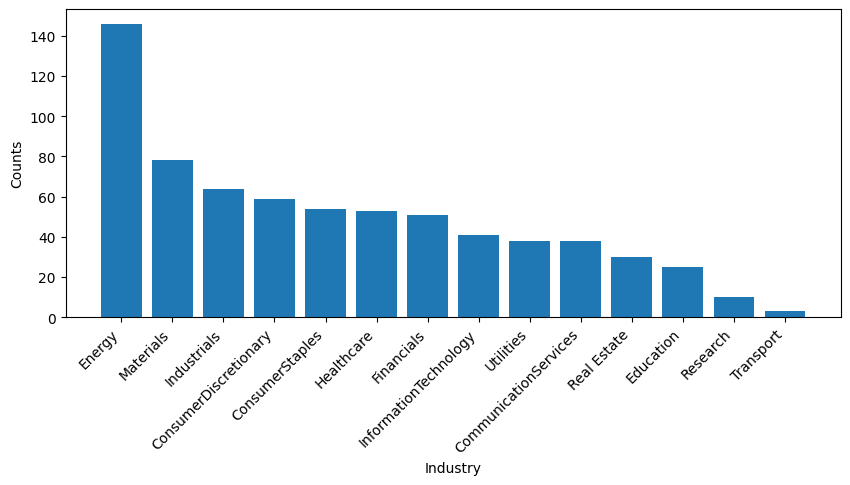

In [ ]:
import matplotlib.pyplot as plt
#Industry
Industry_count = df_application['Industry'].value_counts()
plt.figure(figsize=(10,4))
plt.bar(Industry_count.index, Industry_count)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Industry')
plt.ylabel('Counts')
plt.show()



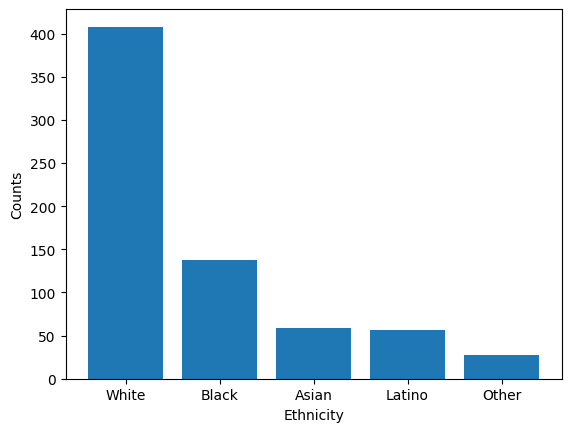

In [ ]:
#Ethnicity
Ethnicity_counts = df_application['Ethnicity'].value_counts()
plt.bar(Ethnicity_counts.index, Ethnicity_counts)
plt.xlabel('Ethnicity')
plt.ylabel('Counts')
plt.show()

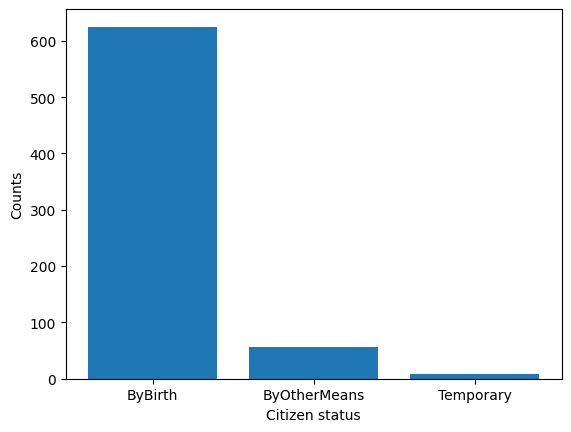

In [ ]:
#Citizen
Citizen_counts = df_application['Citizen'].value_counts()
plt.bar(Citizen_counts.index, Citizen_counts)
plt.xlabel("Citizen status")
plt.ylabel("Counts")
plt.show()

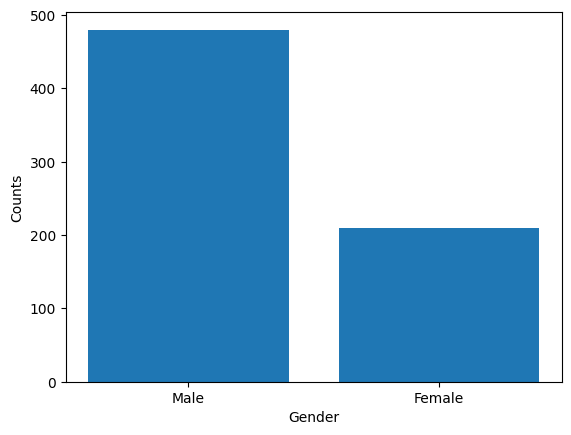

In [ ]:
#Gender
Gender_counts = df_application['Gender'].value_counts()
index = ['Male', 'Female']
Gender_counts.index = index
plt.bar(Gender_counts.index, Gender_counts)
plt.xlabel('Gender')
plt.ylabel('Counts')
plt.show()

Text(0, 0.5, 'Counts')

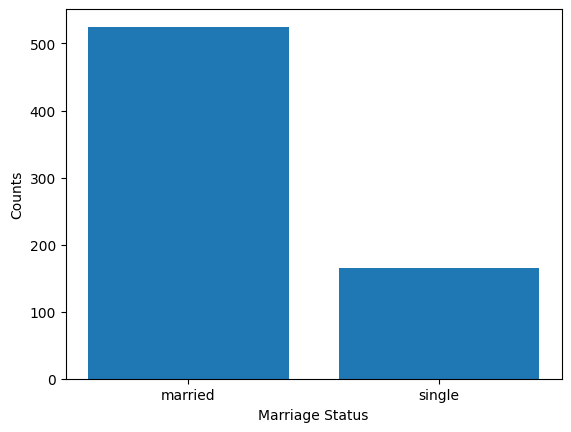

In [ ]:
#Married
married_counts = df_application['Married'].value_counts()
mapping = {0:'single', 1: 'married'}
married_counts = married_counts.rename(index = mapping)
plt.bar(married_counts.index, married_counts)
plt.xlabel('Marriage Status')
plt.ylabel('Counts')

In [ ]:
df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          690 non-null    int64  
 1   Age             690 non-null    float64
 2   Debt            690 non-null    float64
 3   Married         690 non-null    int64  
 4   BankCustomer    690 non-null    int64  
 5   Industry        690 non-null    object 
 6   Ethnicity       690 non-null    object 
 7   YearsEmployed   690 non-null    float64
 8   PriorDefault    690 non-null    int64  
 9   Employed        690 non-null    int64  
 10  CreditScore     690 non-null    int64  
 11  DriversLicense  690 non-null    int64  
 12  Citizen         690 non-null    object 
 13  ZipCode         690 non-null    int64  
 14  Income          690 non-null    int64  
 15  Approved        690 non-null    int64  
dtypes: float64(3), int64(10), object(3)
memory usage: 86.4+ KB


In [ ]:
#check if there is null data
df_application.isnull().sum()

,0
Gender,0
Age,0
Debt,0
Married,0
BankCustomer,0
Industry,0
Ethnicity,0
YearsEmployed,0
PriorDefault,0
Employed,0


#  2. Feature Engineering
We convert the categorical variables into numbers for machine learning by using one-hot encoding and ordinal encoding based on the nature of the data type.

The program transform the feature columns needed for modeling.

* concat method combines two or more dataframe together
* get dummies executes one-hot encoding by converting categorical columns into multiple  0/1 columns

In [ ]:
#clean the dataset
def features(df):
    X = df[['Gender', 'Age', 'Debt', 'Married','BankCustomer', 'YearsEmployed', 'PriorDefault', 'Employed','CreditScore', 'Income']].copy()
    #convert categorical data into dummy variable
    X = pd.concat([X, pd.get_dummies(df['Industry'], prefix='Industry')], axis=1)
    X = pd.concat([X, pd.get_dummies(df['Ethnicity'], prefix='Ethnicity')], axis=1)
    citizen_groups = {
        'ByBirth': 2,
        'ByOtherMeans': 1,
        'Temporary': 0
    }

    X["Citizen_number"] = [citizen_groups[x] for x in df["Citizen"]]
    return X
clean_data = features(df_application)
clean_data.head(20)

,Gender,Age,Debt,Married,BankCustomer,YearsEmployed,PriorDefault,Employed,CreditScore,Income,...,Industry_Real Estate,Industry_Research,Industry_Transport,Industry_Utilities,Ethnicity_Asian,Ethnicity_Black,Ethnicity_Latino,Ethnicity_Other,Ethnicity_White,Citizen_number
0,1,30.83,0.000,1,1,1.250,1,1,1,0,...,False,False,False,False,False,False,False,False,True,2
1,0,58.67,4.460,1,1,3.040,1,1,6,560,...,False,False,False,False,False,True,False,False,False,2
2,0,24.50,0.500,1,1,1.500,1,0,0,824,...,False,False,False,False,False,True,False,False,False,2
3,1,27.83,1.540,1,1,3.750,1,1,5,3,...,False,False,False,False,False,False,False,False,True,2
4,1,20.17,5.625,1,1,1.710,1,0,0,0,...,False,False,False,False,False,False,False,False,True,1
5,1,32.08,4.000,1,1,2.500,1,0,0,0,...,False,False,False,False,False,False,False,False,True,2
6,1,33.17,1.040,1,1,6.500,1,0,0,31285,...,False,False,True,False,False,True,False,False,False,2
7,0,22.92,11.585,1,1,0.040,1,0,0,1349,...,False,False,False,False,False,False,False,False,True,2
8,1,54.42,0.500,0,0,3.960,1,0,0,314,...,False,False,False,False,False,True,False,False,False,2
9,1,42.50,4.915,0,0,3.165,1,0,0,1442,...,False,False,False,False,False,False,False,False,True,2


## 2.1 Clean dataset

After processing the dataset, we stored it in clean_data and check the data type of each column using info method

In [ ]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          690 non-null    int64  
 1   Age                             690 non-null    float64
 2   Debt                            690 non-null    float64
 3   Married                         690 non-null    int64  
 4   BankCustomer                    690 non-null    int64  
 5   YearsEmployed                   690 non-null    float64
 6   PriorDefault                    690 non-null    int64  
 7   Employed                        690 non-null    int64  
 8   CreditScore                     690 non-null    int64  
 9   Income                          690 non-null    int64  
 10  Industry_CommunicationServices  690 non-null    bool   
 11  Industry_ConsumerDiscretionary  690 non-null    bool   
 12  Industry_ConsumerStaples        690 

## 2.2 Target Column
We stored the target column as y dataset

In [ ]:
y = df_application['Approved'].copy()

# 3. Train the model
In this project, we planned to train the dataset using different approach and comparing which method has the best accuracy rate.

* Logistic Regression: Predict the probability using a logistic function on a linear combination of features
* K-Neighbors Classifier: Classify based on the majority of its k nearest neighbors
* MLP Classifier: Using multi layer of neurons to make a prediction

## 3.1 Split the dataset into testing data and training data
Train_test_split from the sklearn library was used to split the data into training and testing sets, with 80% for training and 20% for testing.

Notice that random_state parameter is set to 42, which ensures that reruning the code will consistently produce the same split, making the results reproducible.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(clean_data, y, test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
#for visualization
import matplotlib.pyplot as plt
import seaborn as sns


## 3.2 Standardize features
Columns like ages, YearsEmployed, and income might have a significant different range.
Standardizing these columns ensure that each variable equally impact the prediction

* fit_transform: applied to the training set to compute the mean and standard deviation

* transform: applied to the testing set using the same parameters

In [ ]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###  3.3 Logistic Regression

In [ ]:
# Logistic Regression
lrmodel = LogisticRegression()
lrmodel.fit(X_train_scaled, y_train)

y_pred_lr = lrmodel.predict(X_test_scaled)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr)}")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8260869565217391
              precision    recall  f1-score   support

           0       0.81      0.84      0.83        68
           1       0.84      0.81      0.83        70

    accuracy                           0.83       138
   macro avg       0.83      0.83      0.83       138
weighted avg       0.83      0.83      0.83       138



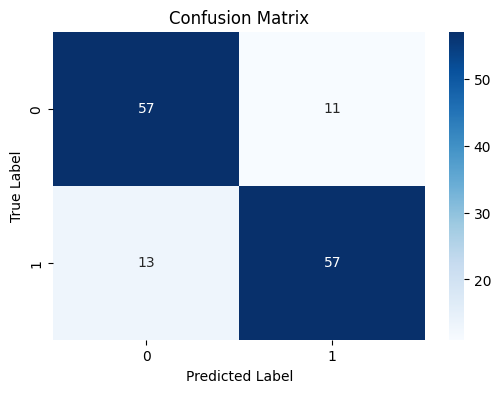

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### 3.4 K-Neighbors Classifier
We used the nearest 5 neighbors for prediction

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model_K = KNeighborsClassifier(n_neighbors=5)
model_K.fit(X_train_scaled, y_train)
y_pred_k =model_K.predict(X_test_scaled)
print(f"KNeighbors Classifier Accuracy: {accuracy_score(y_test, y_pred_k)}")
print(classification_report(y_test, y_pred_k))

KNeighbors Classifier Accuracy: 0.7681159420289855
              precision    recall  f1-score   support

           0       0.74      0.82      0.78        68
           1       0.81      0.71      0.76        70

    accuracy                           0.77       138
   macro avg       0.77      0.77      0.77       138
weighted avg       0.77      0.77      0.77       138



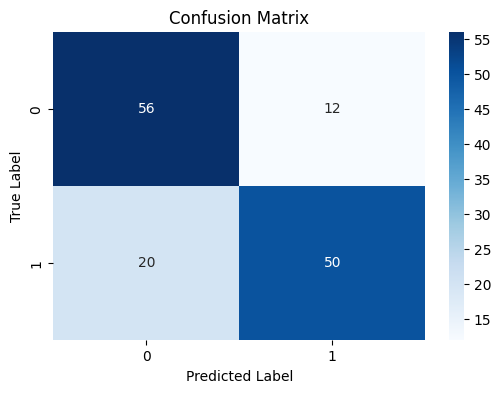

In [ ]:
cm = confusion_matrix(y_test, y_pred_k)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

###  3.5 MLP Classifier
* solver: 'lbfgs' a quasi-Newton method used to optimize the network's weights during training, preform better on small data
* alpha: prevent overfitting
* hidden_layer_sizes: We tried several combination, including (32, 16, 8), (16,8), (8,4). (8,2) preforms the best
* random_state: 11, ensures reproducible results
* max_iter: maximum numbers of iteration

In [ ]:
from sklearn.neural_network import MLPClassifier
mlp_classifier = MLPClassifier(solver='lbfgs', alpha=1e-5,
                               hidden_layer_sizes=(8,2), random_state=11,max_iter=10000)
mlp_classifier.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_classifier.predict(X_test_scaled)
print(f"MLP Classifier Accuracy: {accuracy_score(y_test, y_pred_mlp)}")
print(classification_report(y_test, y_pred_mlp))


MLP Classifier Accuracy: 0.7971014492753623
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        68
           1       0.80      0.80      0.80        70

    accuracy                           0.80       138
   macro avg       0.80      0.80      0.80       138
weighted avg       0.80      0.80      0.80       138



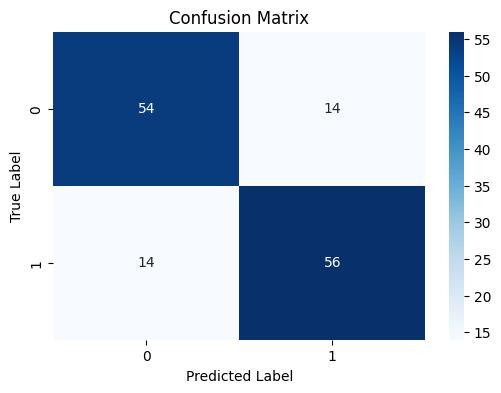

In [ ]:
cm = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 4. Evaluation
Out of the three methods, MLP and logistic regression have a similar accuracy rate of 0.79 and 0.82 respectively. K-neighbors approach preformed poorly with a roughly 0.76 accuracy rate. Investigating deeper in the metrics, we can see that  logistic regression has the highest precision, recall, and accuracy score.

From a customer's perspective, recall is extremely important, as being rejected for a credit card can be harmful and frustrating. A model with higher recall reduces the chance of wrongly denying eligible applicants. Because logistic regression has the highest recall among the competitive models, it would be the most customer-friendly choice.

# 5. Visualization

## 5.1 Sample data
After evaluating the models, we chose logistic regression as our option to process on. We created a sample data, a sophomore college white girl with a part-time job.

In [ ]:
import numpy as np

Gender = 0
Age = 19
Debt = 0
Married = 0
BankCustomer = 1
YearsEmployed = 0
PriorDefault = 1
Employed = 1
CreditScore = 6
Income = 5000
Industry_CommunicationServices =0
Industry_ConsumerDiscretionary =0
Industry_ConsumerStaples =0
Industry_Education = 0
Industry_Energy = 0
Industry_Financials = 0
Industry_Healthcare = 0
Industry_Industrials = 0
Industry_InformationTechnology = 0
Industry_Materials = 0
Industry_Real_Estate = 0
Industry_Research = 0
Industry_Transport = 0
Industry_Utilities = 0
Ethnicity_Asian = 0
Ethnicity_Black = 0
Ethnicity_Latino = 0
Ethnicity_Other = 0
Ethnicity_White = 1
Citizen_number = 2

input_data =np.array([[Gender, Age, Debt, Married, BankCustomer, YearsEmployed, PriorDefault, Employed,
        CreditScore, Income,
       Industry_CommunicationServices, Industry_ConsumerDiscretionary,
       Industry_ConsumerStaples, Industry_Education, Industry_Energy,
       Industry_Financials, Industry_Healthcare, Industry_Industrials,
       Industry_InformationTechnology, Industry_Materials,
       Industry_Real_Estate, Industry_Research, Industry_Transport,
       Industry_Utilities, Ethnicity_Asian, Ethnicity_Black,
       Ethnicity_Latino, Ethnicity_Other, Ethnicity_White,
       Citizen_number]])
#scale
input_scaled = scaler.transform(input_data)
# Predict
y_predicted_lr = lrmodel.predict(input_scaled)
score = lrmodel.predict_proba(input_scaled)

if y_predicted_lr[0] == 1:
    print(f"The application is likely to get accepted (classifier confidence = {score[0][1]:.4f})")
else:
    print(f"The application will get rejected (classifier confidence = {score[0][0]:.4f})")

The application is likely to get accepted (classifier confidence = 0.9683)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 5.2 Coefficient
To identify which features had the most impact on credit card approvals / rejections, we used logistic regression to calculate the coefficients of each feature.

In [ ]:
# Coefficients from the trained LR model
lr_coeffs = pd.Series(lrmodel.coef_[0], index=X_train.columns)

# Sort by impact (absolute value)
lr_coeffs_sorted = lr_coeffs.abs().sort_values(ascending=False)
lr_coeffs_sorted.head(20)

# Build a simple coefficient table for presentation
coef_table = pd.DataFrame({
    "Coefficient": lr_coeffs,
    "Abs(Coefficient)": lr_coeffs.abs()
}).sort_values("Abs(Coefficient)", ascending=False)

coef_table.head(20)


,Coefficient,Abs(Coefficient)
Income,1.946778,1.946778
PriorDefault,1.825586,1.825586
Industry_Healthcare,-0.529589,0.529589
Industry_Utilities,0.503228,0.503228
CreditScore,0.486866,0.486866
Industry_InformationTechnology,0.360449,0.360449
Employed,0.337977,0.337977
Citizen_number,-0.301236,0.301236
Age,0.266574,0.266574
Industry_Research,-0.216589,0.216589


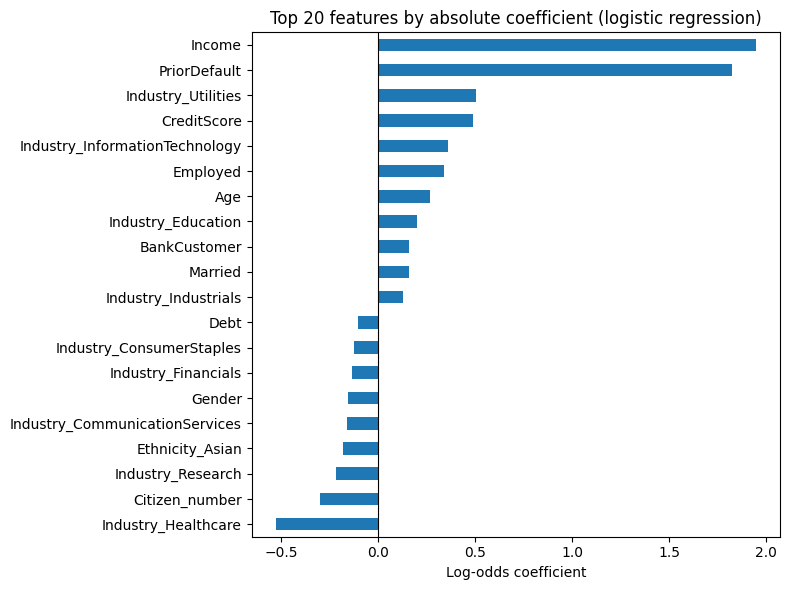

In [ ]:
coef = pd.Series(lrmodel.coef_[0], index=X_train.columns)
top_n = 20
top_features = coef.abs().sort_values(ascending=False).head(top_n).index

plot_coefs = coef.loc[top_features].sort_values()

plt.figure(figsize=(8, max(4, 0.3 * len(plot_coefs))))
plot_coefs.plot(kind='barh')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Log-odds coefficient")
plt.title(f"Top {len(plot_coefs)} features by absolute coefficient (logistic regression)")
plt.tight_layout()
plt.show()
